In [1]:
# ---- core & plotting -------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from enum import Enum
from copy import deepcopy

# ---- SCNN ------------------------------------------------------------
from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

# ---- typed enum ------------------------------------------------------
class Device(str, Enum):
    CPU = "cpu"; CUDA = "cuda"; MPS = "mps"


# ---- experiment configuration ---------------------------------------
@dataclass
class CFG:
    tickers         = ("AAPL", "MSFT", "GOOG")
    prediction_cols = ("log_ret", "sigma20", "Volume")
    split_date      = "2018-01-02"      # first OOS day
    p_lags          = 32
    calib_frac      = 0.20              # 20 % of OOS → calibration
    max_neurons     = 2048              # ← tuned
    lam_gl1         = 3e-5              # ← tuned
    device          = Device.CPU
    data_dir        = Path(".")
    file_tpl        = "{tkr}_2005_2021_clean.csv"
    seed            = 42               # base seed  (will tweak per τ)

CFG = CFG()          # instantiate

In [2]:
def _flatten(col_tup):
    for lvl in col_tup:
        s = str(lvl).strip()
        if s and not s.lower().startswith("unnamed") and s != "nan":
            return s
    return "_".join(str(lvl).strip() for lvl in col_tup if str(lvl) != "nan")

def prepare_from_csv(file_path: Path, cfg: CFG = CFG):
    df = pd.read_csv(file_path, header=[0, 1], index_col=0, parse_dates=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [_flatten(t) for t in df.columns]
    df.index = df.index.normalize()

    req = list(cfg.prediction_cols)
    if missing := [c for c in req if c not in df.columns]:
        raise KeyError(f"{file_path.name}: missing {missing}")

    split_idx = df.index.get_loc(pd.to_datetime(cfg.split_date))
    seasonality = {}

    if "Volume" in req:
        roll = df["Volume"].shift(1).rolling(30, min_periods=1).median()
        df["Volume"] = df["Volume"] / roll
        seasonality["Volume"] = roll

    for col in req:
        lo = df[col].iloc[:split_idx].min()
        hi = df[col].iloc[:split_idx].max()
        df[col] = (df[col] - lo) / (hi - lo)

    df = df[req].dropna()

    X, tgt = [], {c: [] for c in req}
    for i in range(cfg.p_lags, len(df)):
        X.append(df.iloc[i - cfg.p_lags : i].values.flatten())
        for col in req:
            tgt[col].append(df.iloc[i][col])
    X = np.asarray(X)

    rel_split = split_idx - cfg.p_lags
    cut = rel_split + int(cfg.calib_frac * (len(X) - rel_split))
    X_tr, X_cal, X_te = X[:rel_split], X[rel_split:cut], X[cut:]

    tgt_dict = {c: (np.asarray(v[:rel_split]),
                    np.asarray(v[rel_split:cut]),
                    np.asarray(v[cut:]))
                for c, v in tgt.items()}

    idx_cal  = df.index[cfg.p_lags:][rel_split:cut]
    idx_test = df.index[cfg.p_lags:][cut:]

    if "Volume" in seasonality:
        seasonality["Volume"] = seasonality["Volume"].loc[idx_test].values

    return (X_tr, X_cal, X_te,
            tgt_dict,
            idx_cal, idx_test,
            seasonality)


In [3]:
def fit_quantile(X_tr, X_cal, X_te,
                 y_tr, y_cal, y_te,
                 tau: float, cfg: CFG):
    """train one SCNN with pinball loss at quantile τ"""
    mdl, _ = optimize(
        formulation   = "gated_relu",
        max_neurons   = cfg.max_neurons,
        X_train       = X_tr,
        y_train       = y_tr,
        X_test        = X_cal,    # early-stop metric
        y_test        = y_cal,
        bias          = True,
        loss_type     = "pinball",
        pinball_tau   = tau,
        regularizer   = NeuronGL1(cfg.lam_gl1),
        device        = cfg.device,
        verbose       = False,
        seed          = cfg.seed,          # ← pass varying seed
    )
    return mdl, (mdl(X_tr).ravel(), mdl(X_cal).ravel(), mdl(X_te).ravel())
def cqr_univariate(X_blocks, y_blocks,
                   alpha: float = 0.10,
                   base_cfg: CFG = CFG):
    X_tr, X_cal, X_te = X_blocks
    y_tr, y_cal, y_te = y_blocks

    # lower quantile  τ_lo
    cfg_lo         = deepcopy(base_cfg)
    cfg_lo.seed    = base_cfg.seed
    _, q_lo        = fit_quantile(X_tr, X_cal, X_te,
                                  y_tr, y_cal, y_te,
                                  tau=alpha/2, cfg=cfg_lo)

    # upper quantile  τ_hi  with different seed
    cfg_hi         = deepcopy(base_cfg)
    cfg_hi.seed    = base_cfg.seed + 777
    _, q_hi        = fit_quantile(X_tr, X_cal, X_te,
                                  y_tr, y_cal, y_te,
                                  tau=1-alpha/2, cfg=cfg_hi)

    _, qlo_cal, qlo_te = q_lo
    _, qhi_cal, qhi_te = q_hi

    eps    = np.maximum(0.0, np.maximum(qlo_cal - y_cal,
                                        y_cal   - qhi_cal))
    q_conf = np.quantile(eps, 1 - alpha)

    return {
        "lower": qlo_te - q_conf,
        "upper": qhi_te + q_conf,
        "truth": y_te,
        "q_conf": q_conf,
    }

In [4]:
blocks = {}          # (tkr, col) → (X_blocks, y_blocks, idx_test)

for tkr in CFG.tickers:
    csv = CFG.data_dir / CFG.file_tpl.format(tkr=tkr)
    X_tr, X_cal, X_te, tgt, _, idx_test, _ = prepare_from_csv(csv, CFG)

    for col in CFG.prediction_cols:
        y_tr, y_cal, y_te = tgt[col]
        blocks[(tkr, col)] = ((X_tr, X_cal, X_te),
                              (y_tr, y_cal, y_te),
                              idx_test)
print("Loaded blocks:", list(blocks)[:3], "…")


Loaded blocks: [('AAPL', 'log_ret'), ('AAPL', 'sigma20'), ('AAPL', 'Volume')] …


/Users/aqibsyed/Documents/Spring 2025/EE 364b/Final Project/scnn/scnn_zahedi_syed/src/scnn/private/models/regularizers/group_l1.py:80: RuntimeWarning: divide by zero encountered in divide
  * lab.smin(self.lam / grad_norms, 1)


AAPL coverage = 90.07%  (target 90%; q_conf=0.0916)


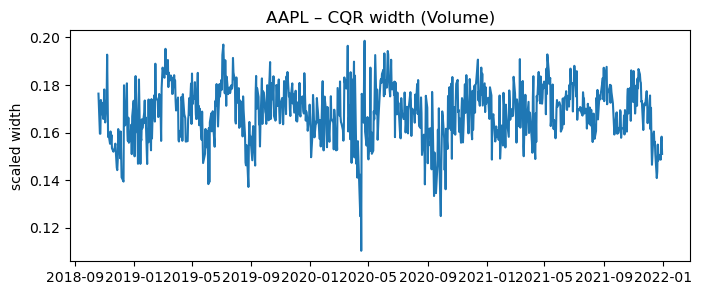

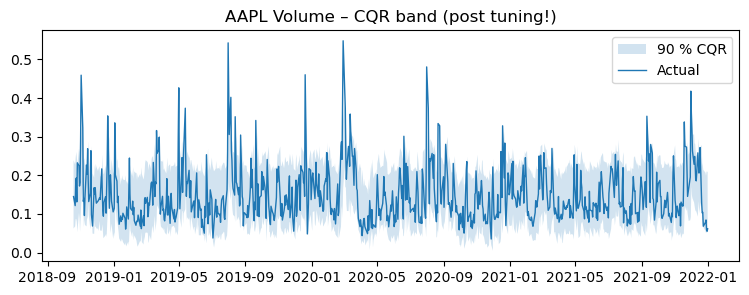

In [5]:
tkr   = "AAPL"
alpha = 0.10

Xb, yb, idx_test = blocks[(tkr, "Volume")]

out   = cqr_univariate(Xb, yb, alpha=alpha, base_cfg=CFG)

cover = ((out["truth"] >= out["lower"])
         & (out["truth"] <= out["upper"])).mean()
print(f"{tkr} coverage = {cover:6.2%}  (target {(1-alpha):.0%}; "
      f"q_conf={out['q_conf']:.4f})")

# ---- width & band plots ---------------------------------------------
plt.figure(figsize=(8,3))
plt.plot(idx_test, out["upper"] - out["lower"])
plt.title(f"{tkr} – CQR width (Volume)"); plt.ylabel("scaled width"); plt.show()

plt.figure(figsize=(9,3))
plt.fill_between(idx_test, out["lower"], out["upper"], alpha=0.2,
                 label="90 % CQR")
plt.plot(idx_test, out["truth"], lw=1, label="Actual")
plt.title(f"{tkr} Volume – CQR band (post tuning!)"); plt.legend(); plt.show()


In [ ]:
tkr   = "AAPL"
alpha = 0.10

Xb, yb, idx_test = blocks[(tkr, "Volume")]

out   = cqr_univariate(Xb, yb, alpha=alpha, base_cfg=CFG)

cover = ((out["truth"] >= out["lower"])
         & (out["truth"] <= out["upper"])).mean()
print(f"{tkr} coverage = {cover:6.2%}  (target {(1-alpha):.0%}; "
      f"q_conf={out['q_conf']:.4f})")

# ---- width & band plots ---------------------------------------------
plt.figure(figsize=(8,3))
plt.plot(idx_test, out["upper"] - out["lower"])
plt.title(f"{tkr} – CQR width (Volume)"); plt.ylabel("scaled width"); plt.show()

plt.figure(figsize=(9,3))
plt.fill_between(idx_test, out["lower"], out["upper"], alpha=0.2,
                 label="90 % CQR")
plt.plot(idx_test, out["truth"], lw=1, label="Actual")
plt.title(f"{tkr} Volume – CQR band (post tuning!)"); plt.legend(); plt.show()


GOOG coverage = 91.32%  (target 90%; q_conf=0.0770)


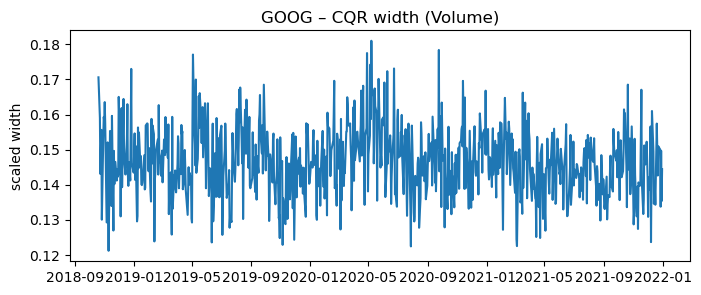

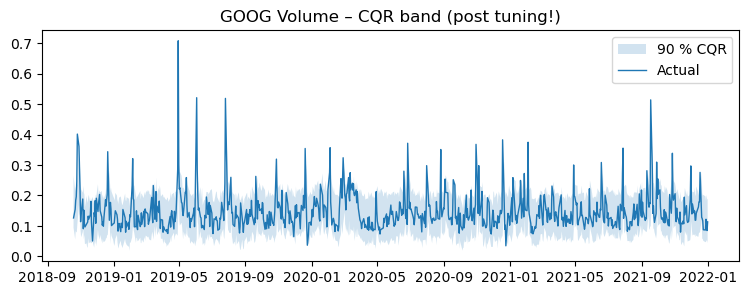

In [7]:
tkr   = "GOOG"
alpha = 0.10

Xb, yb, idx_test = blocks[(tkr, "Volume")]

out   = cqr_univariate(Xb, yb, alpha=alpha, base_cfg=CFG)

cover = ((out["truth"] >= out["lower"])
         & (out["truth"] <= out["upper"])).mean()
print(f"{tkr} coverage = {cover:6.2%}  (target {(1-alpha):.0%}; "
      f"q_conf={out['q_conf']:.4f})")

# ---- width & band plots ---------------------------------------------
plt.figure(figsize=(8,3))
plt.plot(idx_test, out["upper"] - out["lower"])
plt.title(f"{tkr} – CQR width (Volume)"); plt.ylabel("scaled width"); plt.show()

plt.figure(figsize=(9,3))
plt.fill_between(idx_test, out["lower"], out["upper"], alpha=0.2,
                 label="90 % CQR")
plt.plot(idx_test, out["truth"], lw=1, label="Actual")
plt.title(f"{tkr} Volume – CQR band (post tuning!)"); plt.legend(); plt.show()


MSFT coverage = 92.31%  (target 90%; q_conf=0.0462)


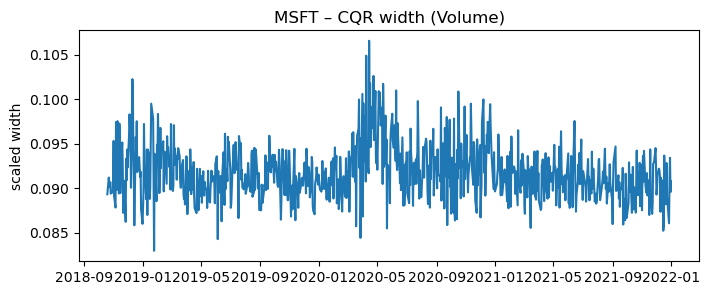

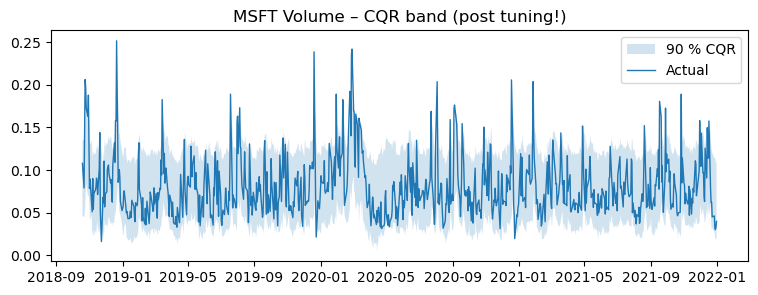

In [6]:
tkr   = "MSFT"
alpha = 0.10

Xb, yb, idx_test = blocks[(tkr, "Volume")]

out   = cqr_univariate(Xb, yb, alpha=alpha, base_cfg=CFG)

cover = ((out["truth"] >= out["lower"])
         & (out["truth"] <= out["upper"])).mean()
print(f"{tkr} coverage = {cover:6.2%}  (target {(1-alpha):.0%}; "
      f"q_conf={out['q_conf']:.4f})")

# ---- width & band plots ---------------------------------------------
plt.figure(figsize=(8,3))
plt.plot(idx_test, out["upper"] - out["lower"])
plt.title(f"{tkr} – CQR width (Volume)"); plt.ylabel("scaled width"); plt.show()

plt.figure(figsize=(9,3))
plt.fill_between(idx_test, out["lower"], out["upper"], alpha=0.2,
                 label="90 % CQR")
plt.plot(idx_test, out["truth"], lw=1, label="Actual")
plt.title(f"{tkr} Volume – CQR band (post tuning!)"); plt.legend(); plt.show()


In [8]:
V_lower = {tkr: out["lower"] for tkr, out in cqr_vol.items()}

NameError: name 'cqr_vol' is not defined

In [ ]:
V_lower = {tkr: out["lower"] for tkr, out in cqr_vol.items()}


## Back-test the robust strategy and compare PnL vs. the point-forecast version.

## Old stuff

In [1]:
import importlib, sys
for m in list(sys.modules):
    if m.startswith("scnn"):
        importlib.reload(sys.modules[m])

In [2]:
%load_ext autoreload
%autoreload 2          

In [3]:
from scnn.optimize import optimize
import numpy as np
X = np.random.randn(20, 3)
y = np.random.randn(20)
optimize("gated_relu", 8, X, y, loss_type="pinball", pinball_tau=0.1)
print("pinball path works!")


pinball path works!


In [1]:
# ---- core & plotting -------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from enum import Enum

# ---- SCNN ------------------------------------------------------------
from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

# ---- typed enums -----------------------------------------------------
class Device(str, Enum):
    CPU="cpu"; CUDA="cuda"; MPS="mps"

# ---- experiment configuration ---------------------------------------
@dataclass
class CFG:
    tickers         = ("AAPL", "MSFT", "GOOG")
    prediction_cols = ("log_ret", "sigma20", "Volume")
    split_date      = "2018-01-02"   # first OOS day
    p_lags          = 32
    calib_frac      = 0.20           # 20 % of OOS → calibration set
    max_neurons     = 512
    lam_gl1         = 1e-3
    device          = Device.CPU
    data_dir        = Path(".")
    file_tpl        = "{tkr}_2005_2021_clean.csv"

CFG = CFG()        # instantiate




In [2]:
# ---------------------------------------------------------------------
#  Flatten CSV header helper
# ---------------------------------------------------------------------
def _flatten(col_tup):
    for lvl in col_tup:
        s = str(lvl).strip()
        if s and not s.lower().startswith("unnamed") and s != "nan":
            return s
    return "_".join(str(lvl).strip() for lvl in col_tup if str(lvl) != "nan")

# ---------------------------------------------------------------------
#  Loader that returns 3 blocks + seasonality factors
# ---------------------------------------------------------------------
def prepare_from_csv(file_path: Path, cfg: CFG=CFG):
    df = pd.read_csv(file_path, header=[0, 1], index_col=0, parse_dates=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [_flatten(t) for t in df.columns]
    df.index = df.index.normalize()

    # --- verify ------------------------------------------------------
    req = list(cfg.prediction_cols)
    if missing := [c for c in req if c not in df.columns]:
        raise KeyError(f"{file_path.name}: missing {missing}")

    split_idx = df.index.get_loc(pd.to_datetime(cfg.split_date))
    seasonality = {}

    # --- volume seasonality -----------------------------------------
    if "Volume" in req:
        roll = df["Volume"].shift(1).rolling(30, min_periods=1).median()
        df["Volume"] = df["Volume"] / roll
        seasonality["Volume"] = roll

    # --- min–max scale ----------------------------------------------
    for col in req:
        lo = df[col].iloc[:split_idx].min()
        hi = df[col].iloc[:split_idx].max()
        df[col] = (df[col] - lo) / (hi - lo)

    df = df[req].dropna()

    # --- lagged design ----------------------------------------------
    X, tgt = [], {c: [] for c in req}
    for i in range(cfg.p_lags, len(df)):
        X.append(df.iloc[i-cfg.p_lags:i].values.flatten())
        for col in req:
            tgt[col].append(df.iloc[i][col])
    X = np.asarray(X)

    # --- three-way split --------------------------------------------
    rel_split = split_idx - cfg.p_lags
    cut = rel_split + int(cfg.calib_frac * (len(X) - rel_split))
    X_tr, X_cal, X_te = X[:rel_split], X[rel_split:cut], X[cut:]

    tgt_dict = {c: (np.asarray(v[:rel_split]),
                    np.asarray(v[rel_split:cut]),
                    np.asarray(v[cut:]))
                for c, v in tgt.items()}

    idx_cal  = df.index[cfg.p_lags:][rel_split:cut]
    idx_test = df.index[cfg.p_lags:][cut:]

    if "Volume" in seasonality:
        seasonality["Volume"] = seasonality["Volume"].loc[idx_test].values

    return (X_tr, X_cal, X_te,
            tgt_dict,
            idx_cal, idx_test,
            seasonality)



In [3]:
def fit_quantile(X_tr, X_cal, X_te,
                 y_tr, y_cal, y_te,
                 tau: float, cfg=CFG):
    mdl, _ = optimize(
        formulation   = "gated_relu",
        max_neurons   = cfg.max_neurons,
        X_train       = X_tr,
        y_train       = y_tr,
        X_test        = X_cal,
        y_test        = y_cal,
        bias          = True,
        loss_type     = "pinball",
        pinball_tau   = tau,
        regularizer   = NeuronGL1(cfg.lam_gl1),
        device        = cfg.device,
        verbose       = False,
    )
    return mdl, (mdl(X_tr).ravel(), mdl(X_cal).ravel(), mdl(X_te).ravel())

def cqr_univariate(X_blocks, y_blocks,
                   alpha: float = 0.10, cfg=CFG):
    X_tr, X_cal, X_te = X_blocks
    y_tr, y_cal, y_te = y_blocks

    tau_lo, tau_hi = alpha/2, 1-alpha/2
    _, q_lo = fit_quantile(X_tr, X_cal, X_te, y_tr, y_cal, y_te, tau_lo, cfg)
    _, q_hi = fit_quantile(X_tr, X_cal, X_te, y_tr, y_cal, y_te, tau_hi, cfg)

    _, qlo_cal, qlo_te = q_lo
    _, qhi_cal, qhi_te = q_hi

    # ---------- FIX: element-wise max of three arrays ----------------
    eps = np.maximum(0.0, np.maximum(qlo_cal - y_cal,
                                     y_cal   - qhi_cal))
    # -----------------------------------------------------------------
    q_conf = np.quantile(eps, 1 - alpha)

    return {
        "lower": qlo_te - q_conf,
        "upper": qhi_te + q_conf,
        "truth": y_te,
        "q_conf": q_conf,
    }

In [4]:
blocks = {}          # (tkr, col) → (X_blocks, y_blocks, idx_test)

for tkr in CFG.tickers:
    csv = CFG.data_dir / CFG.file_tpl.format(tkr=tkr)
    X_tr, X_cal, X_te, tgt, _, idx_test, _ = prepare_from_csv(csv, CFG)

    for col in CFG.prediction_cols:
        y_tr, y_cal, y_te = tgt[col]
        blocks[(tkr, col)] = ((X_tr, X_cal, X_te),
                              (y_tr, y_cal, y_te),
                              idx_test)
print("Loaded blocks:", list(blocks)[:3], "…")


Loaded blocks: [('AAPL', 'log_ret'), ('AAPL', 'sigma20'), ('AAPL', 'Volume')] …


In [6]:
alpha = 0.10
cqr_vol = {}

for tkr in CFG.tickers:
    Xb, yb, _ = blocks[(tkr, "Volume")]
    out = cqr_univariate(Xb, yb, alpha=alpha)
    cqr_vol[tkr] = out

    cover = ((out["truth"] >= out["lower"])
             & (out["truth"] <= out["upper"])).mean()
    print(f"{tkr:<5} coverage = {cover:6.2%}  "
          f"(target {(1-alpha):.0%};  q_conf={out['q_conf']:.4f})")


AAPL  coverage = 92.06%  (target 90%;  q_conf=0.1125)
MSFT  coverage = 93.05%  (target 90%;  q_conf=0.0642)
GOOG  coverage = 91.19%  (target 90%;  q_conf=0.0811)


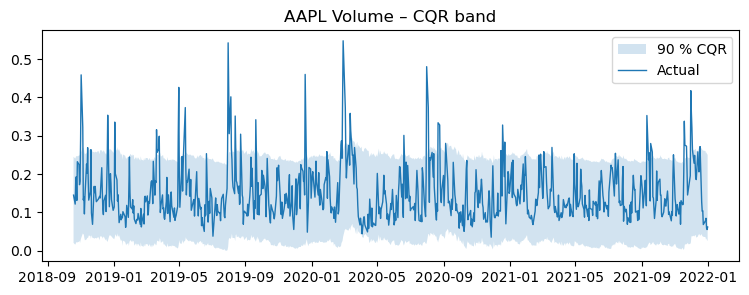

In [7]:
tkr = "AAPL"
out = cqr_vol[tkr]
_, _, idx_test = blocks[(tkr, "Volume")]

plt.figure(figsize=(9,3))
plt.fill_between(idx_test, out["lower"], out["upper"],
                 alpha=0.2, label="90 % CQR")
plt.plot(idx_test, out["truth"], lw=1, label="Actual")
plt.title(f"{tkr} Volume – CQR band"); plt.legend(); plt.show()


In [8]:
for tkr, out in cqr_vol.items():
    widths = out["upper"] - out["lower"]
    print(f"{tkr:<5}  mean-width = {widths.mean():.4f}  "
          f"median = {np.median(widths):.4f}")

AAPL   mean-width = 0.2249  median = 0.2249
MSFT   mean-width = 0.1283  median = 0.1283
GOOG   mean-width = 0.1621  median = 0.1621


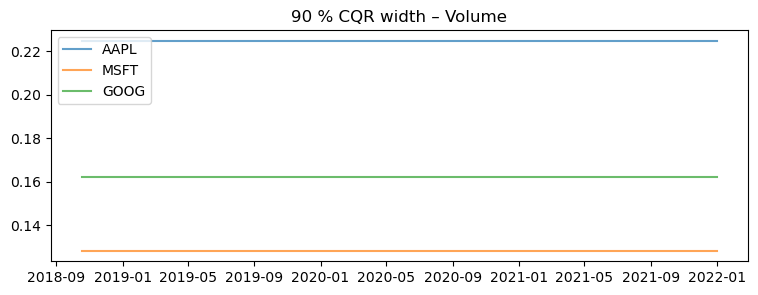

In [13]:
plt.figure(figsize=(9,3))
for tkr, out in cqr_vol.items():
    idx = blocks[(tkr, "Volume")][2]
    plt.plot(idx, out["upper"] - out["lower"], label=tkr, alpha=0.7)
plt.legend(); plt.title("90 % CQR width – Volume"); plt.show()

In [14]:
mdl_lo, _ = fit_quantile(*blocks[("AAPL","Volume")][0],
                         *blocks[("AAPL","Volume")][1],
                         tau=0.05, cfg=CFG)
mdl_hi, _ = fit_quantile(*blocks[("AAPL","Volume")][0],
                         *blocks[("AAPL","Volume")][1],
                         tau=0.95, cfg=CFG)

print("lo  var:", np.var(mdl_lo(blocks[('AAPL','Volume')][0][2])))
print("hi  var:", np.var(mdl_hi(blocks[('AAPL','Volume')][0][2])))

lo  var: 0.0001354932760613739
hi  var: 0.0001354932760613739


AAPL coverage = 90.20%  (target 90%; q_conf=0.0808)


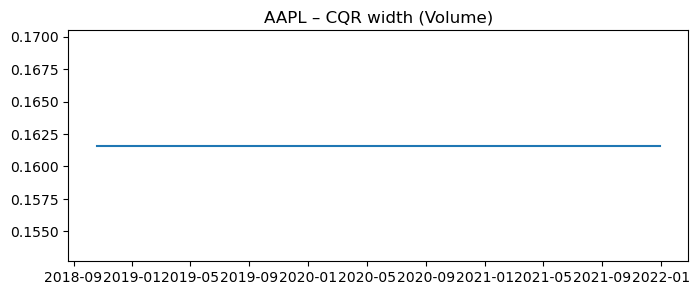

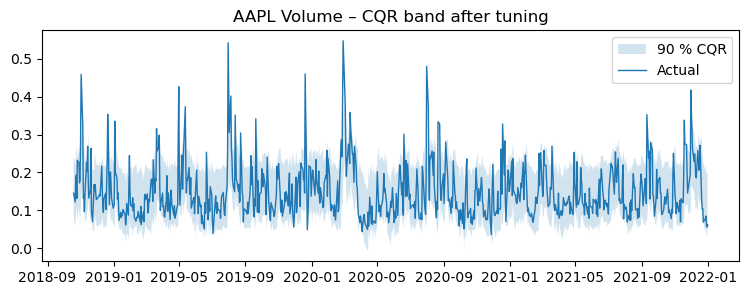

In [8]:
# ---------------------------------------------------------------------
#  Quick sanity loop for ONE ticker (AAPL)
# ---------------------------------------------------------------------
test_cfg = CFG
test_cfg.lam_gl1      = 3e-5     # 10× weaker regularisation
test_cfg.max_neurons  = 2048     # more capacity
tkr   = "AAPL"
alpha = 0.10

# ---- load & split ----------------------------------------------------
csv = test_cfg.data_dir / test_cfg.file_tpl.format(tkr=tkr)
X_tr, X_cal, X_te, tgt, _, idx_test, _ = prepare_from_csv(csv, test_cfg)
y_tr, y_cal, y_te = tgt["Volume"]

# ---- CQR -------------------------------------------------------------
out = cqr_univariate((X_tr, X_cal, X_te),
                     (y_tr, y_cal, y_te),
                     alpha=alpha,
                     cfg=test_cfg)

cover = ((out["truth"] >= out["lower"])
         & (out["truth"] <= out["upper"])).mean()
print(f"{tkr} coverage = {cover:6.2%}  (target {(1-alpha):.0%}; "
      f"q_conf={out['q_conf']:.4f})")

# ---- plot width & band ----------------------------------------------
plt.figure(figsize=(8,3))
plt.plot(idx_test, out["upper"] - out["lower"], label="band width")
plt.title(f"{tkr} – CQR width (Volume)")
plt.show()

plt.figure(figsize=(9,3))
plt.fill_between(idx_test, out["lower"], out["upper"], alpha=0.2,
                 label="90 % CQR")
plt.plot(idx_test, out["truth"], lw=1, label="Actual")
plt.title(f"{tkr} Volume – CQR band after tuning")
plt.legend(); plt.show()

AAPL coverage = 90.20%  (target 90%; q_conf=0.0808)


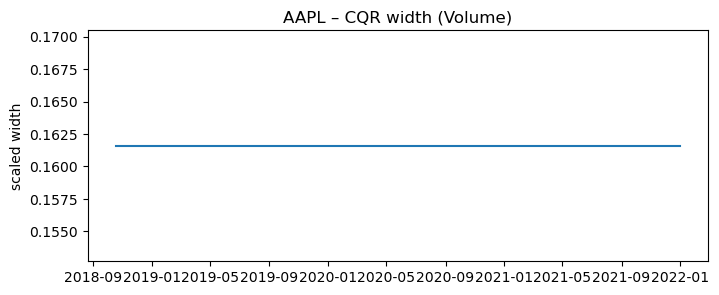

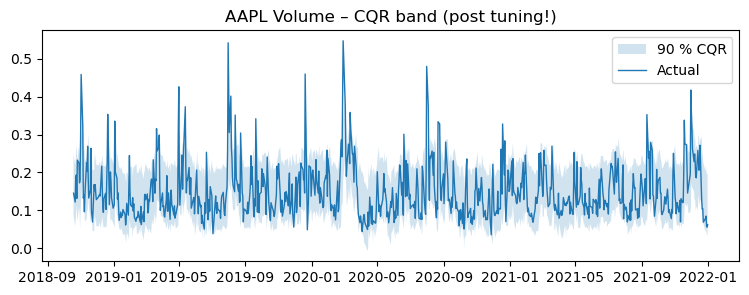

In [6]:
# ---------------------------------------------------------------------
#  One-ticker CQR sanity loop  (AAPL Volume)
# ---------------------------------------------------------------------
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

# --- local config so we don't mutate the global CFG -------------------
test_cfg            = deepcopy(CFG)
test_cfg.lam_gl1    = 3e-5          #  weaker regularisation
test_cfg.max_neurons = 2048         #  larger dictionary

tkr   = "AAPL"
alpha = 0.10

# ---- load & split ----------------------------------------------------
csv = test_cfg.data_dir / test_cfg.file_tpl.format(tkr=tkr)
X_tr, X_cal, X_te, tgt, _, idx_test, _ = prepare_from_csv(csv, test_cfg)
y_tr, y_cal, y_te = tgt["Volume"]

# ---- two quantile fits with *different* seeds -----------------------
lo_seed = 42
hi_seed = 49                       # just offset by a few for diversity
test_cfg.seed = lo_seed
_, q_lo = fit_quantile(X_tr, X_cal, X_te,
                       y_tr, y_cal, y_te,
                       tau=alpha/2, cfg=test_cfg)

test_cfg.seed = hi_seed
_, q_hi = fit_quantile(X_tr, X_cal, X_te,
                       y_tr, y_cal, y_te,
                       tau=1-alpha/2, cfg=test_cfg)

# ---- conformal adjustment -------------------------------------------
_, qlo_cal, qlo_te = q_lo
_, qhi_cal, qhi_te = q_hi
eps     = np.maximum(0.0, np.maximum(qlo_cal - y_cal,
                                     y_cal   - qhi_cal))
q_conf  = np.quantile(eps, 1-alpha)

out = {
    "lower": qlo_te - q_conf,
    "upper": qhi_te + q_conf,
    "truth": y_te,
    "q_conf": q_conf,
}

cover = ((out["truth"] >= out["lower"])
         & (out["truth"] <= out["upper"])).mean()
print(f"{tkr} coverage = {cover:6.2%}  (target {(1-alpha):.0%}; "
      f"q_conf={out['q_conf']:.4f})")

# -------- plot width --------------------------------------------------
plt.figure(figsize=(8,3))
plt.plot(idx_test, out["upper"] - out["lower"])
plt.title(f"{tkr} – CQR width (Volume)"); plt.ylabel("scaled width"); plt.show()

# -------- plot band ---------------------------------------------------
plt.figure(figsize=(9,3))
plt.fill_between(idx_test, out["lower"], out["upper"], alpha=0.2,
                 label="90 % CQR")
plt.plot(idx_test, out["truth"], lw=1, label="Actual")
plt.title(f"{tkr} Volume – CQR band (post tuning!)"); plt.legend(); plt.show()